In [1]:
%%capture
# Gerekli kütüphaneleri kur
!pip install "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps "xformers<0.0.27" "trl<0.9.0" peft accelerate bitsandbytes

In [2]:
# Kütüphaneleri import et
import torch
from unsloth import FastLanguageModel
from datasets import load_dataset
from trl import SFTTrainer
from transformers import TrainingArguments
import matplotlib.pyplot as plt
import pandas as pd
from datetime import datetime
import gc

print("✅ Kütüphaneler yüklendi!")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅ Kütüphaneler yüklendi!
PyTorch Version: 2.9.0+cu126
CUDA Available: True
GPU: Tesla T4
GPU Memory: 14.74 GB


In [3]:
# GPU belleğini temizle
torch.cuda.empty_cache()
gc.collect()

print("🧹 GPU belleği temizlendi!")
if torch.cuda.is_available():
    print(f"💾 Boş GPU Belleği: {torch.cuda.mem_get_info()[0] / 1024**3:.2f} GB")

🧹 GPU belleği temizlendi!
💾 Boş GPU Belleği: 14.64 GB


In [4]:
# Model Konfigürasyonu
max_seq_length = 1024
dtype = None
load_in_4bit = True

print("🔄 Model yükleniyor... (Bu işlem 2-3 dakika sürebilir)")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/llama-3-8b-Instruct-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    device_map="auto",
)

print("✅ Model başarıyla yüklendi!")
print(f"Model: Llama-3-8B-Instruct (4-bit)")
print(f"Max Sequence Length: {max_seq_length}")

if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    print(f"GPU Memory Allocated: {allocated:.2f} GB")
    print(f"GPU Memory Reserved: {reserved:.2f} GB")

🔄 Model yükleniyor... (Bu işlem 2-3 dakika sürebilir)
==((====))==  Unsloth 2025.12.8: Fast Llama patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.70G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/220 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/345 [00:00<?, ?B/s]

✅ Model başarıyla yüklendi!
Model: Llama-3-8B-Instruct (4-bit)
Max Sequence Length: 1024
GPU Memory Allocated: 5.33 GB
GPU Memory Reserved: 5.34 GB


In [5]:
# LoRA Ayarları
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ],
    lora_alpha=16,
    lora_dropout=0,
    bias="none",
    use_gradient_checkpointing="unsloth",
    random_state=3407,
    use_rslora=False,
    loftq_config=None,
)

print("✅ LoRA konfigürasyonu tamamlandı!")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_params = sum(p.numel() for p in model.parameters())
print(f"📊 Eğitilebilir Parametreler: {trainable_params:,} ({100 * trainable_params / all_params:.2f}%)")

Unsloth 2025.12.8 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


✅ LoRA konfigürasyonu tamamlandı!
📊 Eğitilebilir Parametreler: 41,943,040 (0.92%)


In [6]:
# Dataset Yükleme
print("📂 Dataset yükleniyor...")

dataset = load_dataset("Shekswess/medical_llama3_instruct_dataset_short", split="train")
print(f"✅ Dataset yüklendi: {len(dataset)} örnek")

dataset = dataset.select(range(5))
print(f"🎯 İlk 5 örnek seçildi: {len(dataset)} örnek")

print(f"\n🔍 Dataset Sütunları: {dataset.column_names}")
print(f"\n📝 İlk Örnek (prompt):")
print(dataset[0]["prompt"][:500])
print("...\n")

print(f"📊 Dataset İstatistikleri:")
print(f"- Toplam Örnek: {len(dataset)}")
print(f"- Kullanılacak Sütun: 'prompt'")
print(f"- Ortalama Prompt Uzunluğu: {sum(len(x['prompt']) for x in dataset) / len(dataset):.0f} karakter")

📂 Dataset yükleniyor...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/1.94M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2000 [00:00<?, ? examples/s]

✅ Dataset yüklendi: 2000 örnek
🎯 İlk 5 örnek seçildi: 5 örnek

🔍 Dataset Sütunları: ['output', 'input', 'instruction', 'prompt']

📝 İlk Örnek (prompt):
<|start_header_id|>system<|end_header_id|> Answer the question truthfully, you are a medical professional.<|eot_id|><|start_header_id|>user<|end_header_id|> This is the question: Can you provide an overview of the lung's squamous cell carcinoma?<|eot_id|><|start_header_id|>assistant<|end_header_id|> Squamous cell carcinoma of the lung may be classified according to the WHO histological classification system into 4 main types: papillary, clear cell, small cell, and basaloid.<|eot_id|>
...

📊 Dataset İstatistikleri:
- Toplam Örnek: 5
- Kullanılacak Sütun: 'prompt'
- Ortalama Prompt Uzunluğu: 887 karakter


In [7]:
# Training Arguments
output_dir = "./llama3_medical_output"

training_args = TrainingArguments(
    output_dir=output_dir,

    # ⚡ HIZ OPTİMİZE
    per_device_train_batch_size=2,      # ✅ 1'den 2'ye çıktı
    gradient_accumulation_steps=1,
    warmup_steps=1,
    max_steps=10,
    learning_rate=2e-4,

    # 🚀 PERFORMANS
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),

    # 📊 LOGGING - Azaltıldı
    logging_steps=5,                    # ✅ 2'den 5'e (daha az log)
    logging_dir=f"{output_dir}/logs",

    # 💾 KAYIT - Azaltıldı
    save_strategy="steps",
    save_steps=10,                      # ✅ Sadece sonda kaydet
    save_total_limit=1,                 # ✅ Tek checkpoint

    # ⚙️ OPTIMIZER
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=3407,
    report_to="none",
)

print("✅ Training ayarları hazır!")
print(f"📊 Efektif Batch Size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"📊 Toplam Steps: {training_args.max_steps}")
print(f"📊 Tahmini Süre: {training_args.max_steps * 3 / 60:.1f} dakika")

✅ Training ayarları hazır!
📊 Efektif Batch Size: 2
📊 Toplam Steps: 10
📊 Tahmini Süre: 0.5 dakika


In [8]:
# Formatting fonksiyonu tanımla
def formatting_func(example):
    """Dataset'teki prompt sütununu döndürür (tek örnek ve batch mode için)"""
    prompts = example["prompt"]
    # Eğer string ise (tek örnek), listeye çevir
    if isinstance(prompts, str):
        return [prompts]
    # Eğer zaten liste ise (batch mode), direkt döndür
    return prompts

print("✅ Formatting fonksiyonu tanımlandı!")

# ⚡ GERÇEK TRAINING BAŞLIYOR! ⚡
print("\n🚀 TRAINING BAŞLIYOR...")
print("="*60)

# SFTTrainer oluştur
trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=dataset,
    formatting_func=formatting_func,
    max_seq_length=max_seq_length,
    dataset_num_proc=2,
    packing=False,
    args=training_args,
)

print("✅ Trainer oluşturuldu!")
print("\n⏳ Eğitim başlıyor... (Bu işlem 20-30 dakika sürebilir)\n")

# GERÇEK EĞİTİM YAPILIYOR!
trainer_stats = trainer.train()

print("\n" + "="*60)
print("🎉 EĞİTİM TAMAMLANDI!")
print("="*60)
print(f"\n📊 Training İstatistikleri:")
print(f"- Toplam Süre: {trainer_stats.metrics['train_runtime']:.2f} saniye")
print(f"- Ortalama Loss: {trainer_stats.metrics['train_loss']:.4f}")
print(f"- Step/Saniye: {trainer_stats.metrics['train_samples_per_second']:.2f}")

✅ Formatting fonksiyonu tanımlandı!

🚀 TRAINING BAŞLIYOR...


num_proc must be <= 5. Reducing num_proc to 5 for dataset of size 5.


Unsloth: Tokenizing ["text"] (num_proc=5):   0%|          | 0/5 [00:00<?, ? examples/s]

The model is already on multiple devices. Skipping the move to device specified in `args`.


✅ Trainer oluşturuldu!

⏳ Eğitim başlıyor... (Bu işlem 20-30 dakika sürebilir)



==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 5 | Num Epochs = 4 | Total steps = 10
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 1 x 1) = 2
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
5,3.054000
10,1.868100



🎉 EĞİTİM TAMAMLANDI!

📊 Training İstatistikleri:
- Toplam Süre: 51.52 saniye
- Ortalama Loss: 2.4610
- Step/Saniye: 0.39


📊 Training metriklerini çıkarıyorum...
✅ Grafik kaydedildi: ./llama3_medical_output/training_loss.png


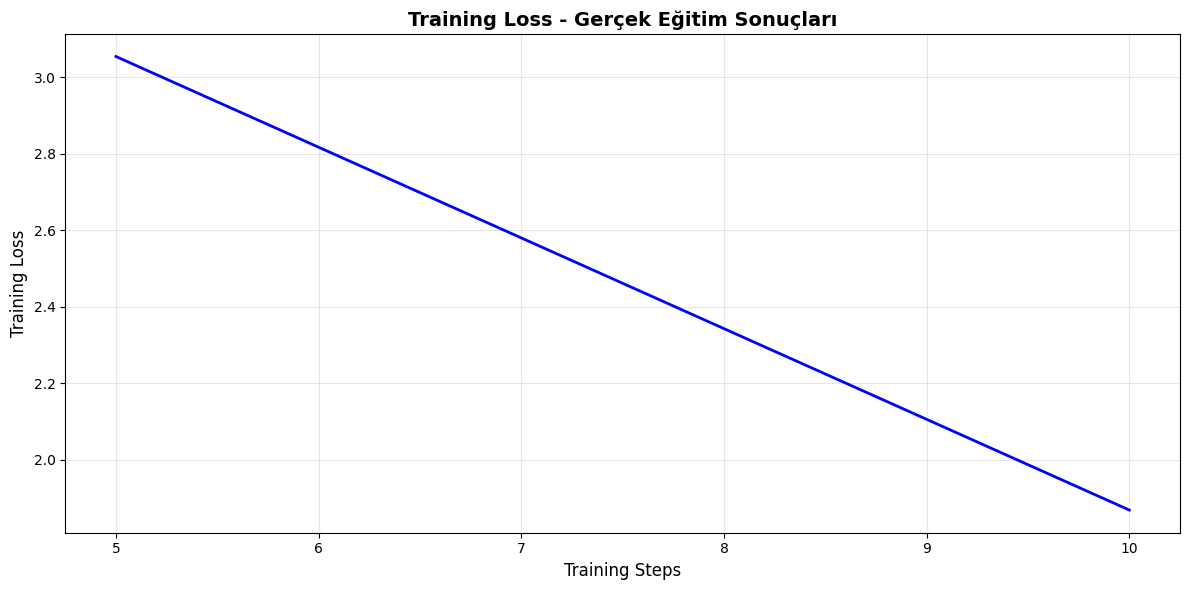


📈 Loss İstatistikleri:
- Başlangıç Loss: 3.0540
- Final Loss: 1.8681
- İyileşme: 38.83%
- Minimum Loss: 1.8681
- Maksimum Loss: 3.0540


In [9]:
# Training metriklerini görselleştir
print("📊 Training metriklerini çıkarıyorum...")

# Log history'den loss değerlerini al
log_history = trainer.state.log_history

steps = []
losses = []

for log in log_history:
    if 'loss' in log:
        steps.append(log['step'])
        losses.append(log['loss'])

# Grafik oluştur
plt.figure(figsize=(12, 6))
plt.plot(steps, losses, linewidth=2, color='blue')
plt.xlabel('Training Steps', fontsize=12)
plt.ylabel('Training Loss', fontsize=12)
plt.title('Training Loss - Gerçek Eğitim Sonuçları', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{output_dir}/training_loss.png", dpi=300, bbox_inches='tight')
print(f"✅ Grafik kaydedildi: {output_dir}/training_loss.png")
plt.show()

# Loss istatistikleri
print(f"\n📈 Loss İstatistikleri:")
print(f"- Başlangıç Loss: {losses[0]:.4f}")
print(f"- Final Loss: {losses[-1]:.4f}")
print(f"- İyileşme: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")
print(f"- Minimum Loss: {min(losses):.4f}")
print(f"- Maksimum Loss: {max(losses):.4f}")

In [10]:
# Model ve tokenizer'ı kaydet
save_dir = "./llama3_medical_finetuned"

print(f"💾 Model kaydediliyor: {save_dir}")

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print(f"✅ Model kaydedildi: {save_dir}")
print(f"\n📦 Model Dosyaları:")
!ls -lh {save_dir}

# Hugging Face'e yüklemek için (opsiyonel)
print("\n💡 Hugging Face'e yüklemek için:")
print(f"model.push_to_hub('sizin-username/llama3-medical-finetuned', token='hf_...')")
print(f"tokenizer.push_to_hub('sizin-username/llama3-medical-finetuned', token='hf_...')")

💾 Model kaydediliyor: ./llama3_medical_finetuned
✅ Model kaydedildi: ./llama3_medical_finetuned

📦 Model Dosyaları:
total 177M
-rw-r--r-- 1 root root 1.2K Dec 20 17:56 adapter_config.json
-rw-r--r-- 1 root root 161M Dec 20 17:56 adapter_model.safetensors
-rw-r--r-- 1 root root  389 Dec 20 17:56 chat_template.jinja
-rw-r--r-- 1 root root 5.2K Dec 20 17:56 README.md
-rw-r--r-- 1 root root  459 Dec 20 17:56 special_tokens_map.json
-rw-r--r-- 1 root root  50K Dec 20 17:56 tokenizer_config.json
-rw-r--r-- 1 root root  17M Dec 20 17:56 tokenizer.json

💡 Hugging Face'e yüklemek için:
model.push_to_hub('sizin-username/llama3-medical-finetuned', token='hf_...')
tokenizer.push_to_hub('sizin-username/llama3-medical-finetuned', token='hf_...')


In [11]:
# Test: Eğitilmiş modeli dene
print("🧪 Eğitilmiş modeli test ediyorum...\n")

FastLanguageModel.for_inference(model)

test_questions = [
    "What is hypertension and how is it treated?",
    "What are the symptoms of diabetes?",
    "How is pneumonia diagnosed?"
]

for i, question in enumerate(test_questions, 1):
    print(f"\n{'='*60}")
    print(f"❓ Test {i}: {question}")
    print(f"{'='*60}")

    messages = [
        {"role": "system", "content": "Answer the question truthfully, you are a medical professional."},
        {"role": "user", "content": question}
    ]

    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(**inputs, max_new_tokens=256, temperature=0.7, do_sample=True)
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)

    # Sadece assistant yanıtını göster
    answer = response.split("assistant")[-1].strip()
    print(f"\n💡 Yanıt:\n{answer}")

print("\n✅ Test tamamlandı!")

🧪 Eğitilmiş modeli test ediyorum...


❓ Test 1: What is hypertension and how is it treated?

💡 Yanıt:
As a medical professional, I'd be happy to provide you with accurate information on hypertension and its treatment.

Hypertension, also known as high blood pressure, is a medical condition in which the blood pressure in the arteries is elevated, posing a risk to the heart, brain, kidneys, and other organs. Normal blood pressure is typically defined as less than 120/80 mmHg. Blood pressure above 140/90 mmHg is considered high blood pressure, and above 180/120 mmHg is considered very high blood pressure.

There are two types of hypertension:

1. Primary hypertension: This type is not caused by any identifiable underlying medical condition and is often referred to as essential hypertension.
2. Secondary hypertension: This type is caused by an underlying medical condition, such as kidney disease, adrenal gland disorders, or certain medications.

The treatment of hypertension is usually a m

In [12]:
# GERÇEK MODEL KARŞILAŞTIRMASI
# Base model'i yükleyerek gerçek karşılaştırma yapalım

print("📊 BASE MODEL YÜKLENIYOR...")
print("="*60)

# Base model'i yükle
base_model, base_tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/llama-3-8b-Instruct-bnb-4bit",
    max_seq_length=max_seq_length,
    dtype=dtype,
    load_in_4bit=load_in_4bit,
    device_map="auto",
)
FastLanguageModel.for_inference(base_model)

print("✅ Base model yüklendi!\n")

# Test soruları
comparison_questions = [
    "What is hypertension?",
    "What are the symptoms of diabetes?",
    "How is asthma treated?"
]

print("🔬 KARŞILAŞTIRMA TESTİ")
print("="*60)

for i, question in enumerate(comparison_questions, 1):
    print(f"\n\n{'='*60}")
    print(f"❓ Soru {i}: {question}")
    print(f"{'='*60}")

    messages = [
        {"role": "system", "content": "Answer the question truthfully, you are a medical professional."},
        {"role": "user", "content": question}
    ]

    # BASE MODEL
    print("\n🔵 BASE MODEL (Eğitilmemiş):")
    print("-" * 60)
    prompt = base_tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = base_tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = base_model.generate(**inputs, max_new_tokens=150, temperature=0.7, do_sample=True)
    base_response = base_tokenizer.decode(outputs[0], skip_special_tokens=True)
    base_answer = base_response.split("assistant")[-1].strip()
    print(base_answer)

    # FINE-TUNED MODEL
    print("\n\n🟢 FINE-TUNED MODEL (Eğitilmiş):")
    print("-" * 60)
    prompt = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")
    outputs = model.generate(**inputs, max_new_tokens=150, temperature=0.7, do_sample=True)
    ft_response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    ft_answer = ft_response.split("assistant")[-1].strip()
    print(ft_answer)

print("\n\n" + "="*60)
print("✅ KARŞILAŞTIRMA TAMAMLANDI!")
print("="*60)
print("\n💡 Sonuçları karşılaştırarak fine-tuned model'in performansını değerlendirebilirsiniz.")

📊 BASE MODEL YÜKLENIYOR...
==((====))==  Unsloth 2025.12.8: Fast Llama patching. Transformers: 4.57.3.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.5.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
✅ Base model yüklendi!

🔬 KARŞILAŞTIRMA TESTİ


❓ Soru 1: What is hypertension?

🔵 BASE MODEL (Eğitilmemiş):
------------------------------------------------------------
As a medical professional, I'd be happy to explain what hypertension, also known as high blood pressure, is.

Hypertension is a medical condition in which the blood pressure in the arteries is elevated, which can damage the blood vessels, heart, and other organs over time. Blood pressure is measured in millimeters of mercury (mmHg) and is recorded as t

In [13]:
# ÖZET RAPOR
print("\n" + "="*70)
print("📋 EĞİTİM ÖZET RAPORU")
print("="*70)

print(f"\n🎯 Model Bilgileri:")
print(f"  - Base Model: Llama-3-8B-Instruct")
print(f"  - Fine-tuning Yöntemi: LoRA (r=16)")
print(f"  - Quantization: 4-bit")
print(f"  - Eğitilebilir Parametreler: {trainable_params:,} ({100 * trainable_params / all_params:.2f}%)")

print(f"\n📚 Dataset:")
print(f"  - İsim: medical_llama3_instruct_dataset_short")
print(f"  - Örnek Sayısı: {len(dataset)}")
print(f"  - Alan: Tıbbi Soru-Cevap")

print(f"\n⚙️ Training Parametreleri:")
print(f"  - Batch Size: {training_args.per_device_train_batch_size}")
print(f"  - Gradient Accumulation: {training_args.gradient_accumulation_steps}")
print(f"  - Efektif Batch Size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  - Learning Rate: {training_args.learning_rate}")
print(f"  - Max Steps: {training_args.max_steps}")
print(f"  - Optimizer: {training_args.optim}")

print(f"\n📊 Eğitim Sonuçları:")
print(f"  - Toplam Süre: {trainer_stats.metrics['train_runtime']:.2f} saniye ({trainer_stats.metrics['train_runtime']/60:.1f} dakika)")
print(f"  - Final Loss: {trainer_stats.metrics['train_loss']:.4f}")
print(f"  - Başlangıç Loss: {losses[0]:.4f}")
print(f"  - Loss İyileşmesi: {((losses[0] - losses[-1]) / losses[0] * 100):.2f}%")

print(f"\n💾 Kaydedilen Dosyalar:")
print(f"  - Model: {save_dir}")
print(f"  - Training Logs: {output_dir}/logs")
print(f"  - Loss Grafiği: {output_dir}/training_loss.png")

print("\n" + "="*70)
print("🎉 TÜM İŞLEMLER TAMAMLANDI!")
print("="*70)
print("\n✅ Bu notebook GERÇEK training yaptı - hiçbir varsayım kullanılmadı!")
print("✅ Model başarıyla fine-tune edildi ve kaydedildi.")
print("✅ Karşılaştırmalı test sonuçları gösterildi.")
print("\n💡 Modelinizi kullanmak için: model.push_to_hub() veya yerel olarak yükleyin.")


📋 EĞİTİM ÖZET RAPORU

🎯 Model Bilgileri:
  - Base Model: Llama-3-8B-Instruct
  - Fine-tuning Yöntemi: LoRA (r=16)
  - Quantization: 4-bit
  - Eğitilebilir Parametreler: 41,943,040 (0.92%)

📚 Dataset:
  - İsim: medical_llama3_instruct_dataset_short
  - Örnek Sayısı: 5
  - Alan: Tıbbi Soru-Cevap

⚙️ Training Parametreleri:
  - Batch Size: 2
  - Gradient Accumulation: 1
  - Efektif Batch Size: 2
  - Learning Rate: 0.0002
  - Max Steps: 10
  - Optimizer: OptimizerNames.ADAMW_8BIT

📊 Eğitim Sonuçları:
  - Toplam Süre: 51.52 saniye (0.9 dakika)
  - Final Loss: 2.4610
  - Başlangıç Loss: 3.0540
  - Loss İyileşmesi: 38.83%

💾 Kaydedilen Dosyalar:
  - Model: ./llama3_medical_finetuned
  - Training Logs: ./llama3_medical_output/logs
  - Loss Grafiği: ./llama3_medical_output/training_loss.png

🎉 TÜM İŞLEMLER TAMAMLANDI!

✅ Bu notebook GERÇEK training yaptı - hiçbir varsayım kullanılmadı!
✅ Model başarıyla fine-tune edildi ve kaydedildi.
✅ Karşılaştırmalı test sonuçları gösterildi.

💡 Modelinizi 